## Titanic Survivor Prediction

In this example, we'll leverage the very popular titanic data set to train a simple binary LR model to predict whether a particular passenger would survive.

### Importing our modules

In [ ]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

![Screenshot%202022-10-17%20075351.png](attachment:Screenshot%202022-10-17%20075351.png)

### Importing the data and performing some EDA

In [ ]:
# importing the dataset
df = pd.read_csv('C:/Users/Romer/Documents/Learning/Pace/Intro to DS/Lecture_5/Data/titanic/train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Descriptive Statistics

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Plotting the target variable

Let's see if there's any major skewness with our target variable in terms of number of survivors versus non-survivors. This can have an impact when training any prediction model.

<AxesSubplot:xlabel='Survived', ylabel='count'>

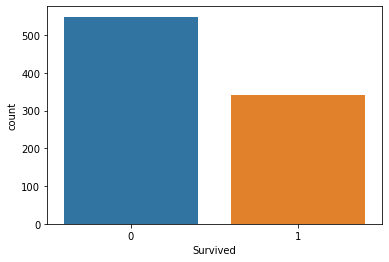

In [ ]:
sns.countplot(x='Survived', data=df)

#### Plotting features

In many cases when trying to assess what categorical features may lend greater importance to a prediction, utilizing simple bar charts that plot a feature against the target variable can provide valuable insights.

Let's see a break-out of gender against survivorship.

<AxesSubplot:xlabel='Survived', ylabel='count'>

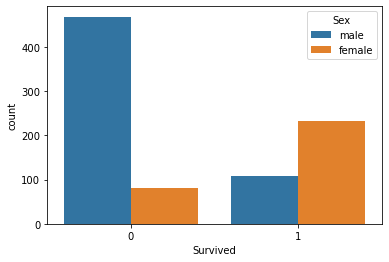

In [ ]:
sns.countplot(x='Survived', hue='Sex', data=df)

We can also check the age distribution in the dataset.

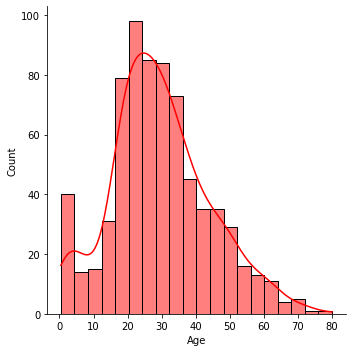

In [ ]:
sns.displot(x='Age', data=df, color='red', kde=True)

#### Count number of unique values for each column

In [ ]:
uValues = df.nunique()
print('In each column the number of unique values are')
print(uValues)

NameError: ignored

#### Check for missing values

In each column the number of missing values are:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


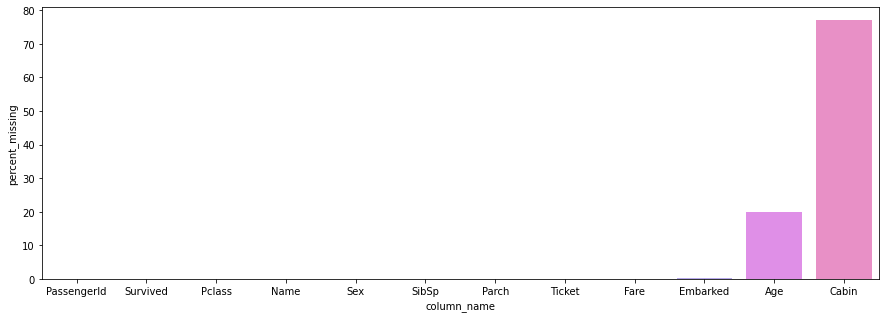

In [ ]:
print('In each column the number of missing values are:')
print(df.isnull().sum())

percent_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = pd.DataFrame({'column_name': df.columns,
                                 'percent_missing': percent_missing})
missing_value_df.sort_values('percent_missing', inplace=True)

# setting the dimensions of the plot
fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(
    x='column_name',
    y='percent_missing',
    #hue='Group',
    data=missing_value_df,
    ax=ax
)
plt.xlabel('column_name')
plt.ylabel('percent_missing')
plt.show()

### Feature Engineering

#### Managing missing values

Variable cabin has too many missing values, we won’t use it. We will also drop PassengerId since it is only an index along with Ticket.


In [ ]:
df_subset = df.drop(['PassengerId','Cabin', 'Ticket'],axis=1)#---axis indicates to drop a column
df_subset.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


We still need to account for missing values in the Age and Embarked fields. There are different ways to do this. When dealing with a numerical field, a typical approach is to replace the missing values with the average, the median or the mode of the existing one. We’ll be using the average.

In [ ]:
# Find the mean of the Age column
age_mean = df_subset['Age'].mean()
# Replace NaN values with the mean
df_subset['Age'] = df_subset['Age'].fillna(age_mean)

#### For missing values in Embarked, since there are only two, we'll discard those two rows.

In [ ]:
df_subset = df_subset.dropna()
print(df_subset.shape)

(889, 9)


#### Check to see all missing values have been removed

In [ ]:
print('In each column the number of missing values are:')
print(df_subset.isnull().sum())

In each column the number of missing values are:
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


#### One-Hot Encoding

Because many machine learning models need their input variables to be numeric, categorical variables need to be transformed in the pre-processing part. Pandas has a function which can turn a categorical variable into a series of zeros and ones, which makes them a lot easier to quantify and compare.

Let’s do OHE, first in the sex column:

In [ ]:
dummy = pd.get_dummies(df_subset['Sex'], drop_first=True)
# Take a look
dummy.head()

,male
0,1
1,0
2,0
3,0
4,1


Let's merge the new column with the subset and drop the old column

In [ ]:
df_subset = pd.concat([df_subset, dummy], axis=1).drop('Sex', axis=1)
df_subset.head()

,Survived,Pclass,Name,Age,SibSp,Parch,Fare,Embarked,male
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,7.2500,S,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,71.2833,C,0
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,7.9250,S,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,53.1000,S,0
4,0,3,"Allen, Mr. William Henry",35.0,0,0,8.0500,S,1


Let’s repeat the process for the Embarked column:

In [ ]:
dummy1 = pd.get_dummies(df_subset['Embarked'])
dummy1.head()

,C,Q,S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


In [ ]:
df_subset = pd.concat([df_subset, dummy1], axis=1).drop('Embarked', axis=1)
df_subset.rename(columns={'C':'Embarked_C','Q':'Embarked_Q','S':'Embarked_S'}, inplace=True)
df_subset.head()

,Survived,Pclass,Name,Age,SibSp,Parch,Fare,male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,7.2500,1,0,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,71.2833,0,1,0,0
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,7.9250,0,0,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,53.1000,0,0,0,1
4,0,3,"Allen, Mr. William Henry",35.0,0,0,8.0500,1,0,0,1


### Splitting the dataset

We will split the data sets into their input (features) and target (label) variables. Then we'll divide the data into training and testing sets so that once the training of the model is complete, we can evaluate its performance using testing data. Specifically, we're assigning 20% of the data to serve as testing data with remaining 80% used to help train the model. Additionally, you can use random_state to select records randomly. Seeding this with a value ensures reproducibility.

In [ ]:
#split dataset into features and target variable
feature_cols = ['Pclass','Age','SibSp','Parch','Fare','male','Embarked_C','Embarked_Q','Embarked_S']
X = df_subset[feature_cols] # Features
y = df_subset.Survived # Target variable

# training and testing data
from sklearn.model_selection import train_test_split

# assign test data size 20%
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size= 0.20, random_state=16)

### Standardizing the data

Standardization (or scaling) makes it easier for machine learning to handle data by ensuring that features more or less fit into a normal distribution curve. Otherwise, you run the risk of the model failing to make reasonable predictions due to large variations in  values.

In [ ]:
# importing standard scaler
from sklearn.preprocessing import StandardScaler

# scalling the input data
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.fit_transform(X_test)

### Importing and training the Logistic Regression model

First, import the Logistic Regression module and create a Logistic Regression classifier object using the LogisticRegression() function with random_state for reproducibility. Then, fit your model on the train set using fit().

In [ ]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

LogisticRegression(random_state=16)

### Running the Predictions

Let's perform prediction on the test set using predict(). Then create a Pandas DataFrame to compare the predicted and actual values.

In [ ]:
y_pred = logreg.predict(X_test)

In [ ]:
result = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred})
result

,Actual,Predicted
55,1,0
617,0,1
660,1,0
516,1,1
246,0,1
...,...,...
508,0,0
379,0,0
645,1,0
836,0,0


#### Coefficients

Let's print out the weights of the coefficients and intercept calculated by the model using coef_ and intercept_ attributes

In [ ]:
importance = logreg.coef_[0]

for i,j in enumerate(importance):
    print('Feature: %0d, Score: %.5f' % (i,j))

for k in enumerate(X.columns):
    print(k)


print('')
print(f'Intercept: {logreg.intercept_}')


Feature: 0, Score: -0.89391
Feature: 1, Score: -0.54335
Feature: 2, Score: -0.40012
Feature: 3, Score: -0.11475
Feature: 4, Score: -0.02002
Feature: 5, Score: -1.27988
Feature: 6, Score: 0.08061
Feature: 7, Score: 0.05262
Feature: 8, Score: -0.10406
(0, 'Pclass')
(1, 'Age')
(2, 'SibSp')
(3, 'Parch')
(4, 'Fare')
(5, 'male')
(6, 'Embarked_C')
(7, 'Embarked_Q')
(8, 'Embarked_S')

Intercept: [-0.71063794]


#### Feature Importance

Let's plot the features to better visualize their relative importance given based on the coefficients

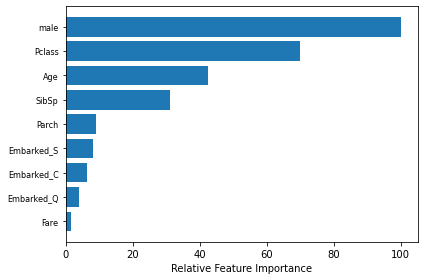

In [ ]:
feature_importance = abs(logreg.coef_[0])
feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5

featfig = plt.figure()
featax = featfig.add_subplot(1, 1, 1)
featax.barh(pos, feature_importance[sorted_idx], align='center')
featax.set_yticks(pos)
featax.set_yticklabels(np.array(X.columns)[sorted_idx], fontsize=8)
featax.set_xlabel('Relative Feature Importance')

plt.tight_layout()
plt.show()

### View the model probabilities assigned

Let's return the matrix of probabilities that the predicted output is equal to zero or one.

In [ ]:
print(logreg.predict_proba(X))

[[9.99999969e-01 3.14356547e-08]
 [1.00000000e+00 3.78004349e-11]
 [9.99999981e-01 1.89350929e-08]
 ...
 [9.99999999e-01 9.90677056e-10]
 [9.99999976e-01 2.43279150e-08]
 [1.00000000e+00 2.37213954e-10]]


C:\Users\Romer\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


From the matrix, each row represents a single observation. The first column is the probability that the passenger did not survive (0), and the second column is the probability that the passenger did survive(0).

### Model Evaluation using Confusion Matrix

A confusion matrix is a table that is used to evaluate the performance of a classification model. The fundamental of a confusion matrix is the number of correct and incorrect predictions summed up class-wise. Here, we'll visualize the confusion matrix using a Heatmap.

Text(0.5, 257.44, 'Predicted label')

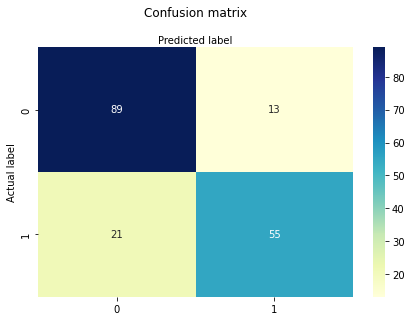

In [ ]:
# import the metrics class
from sklearn import metrics

# passing actual and predicted values
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

### Classification Report for Evaluation Metrics

Let's evaluate the model using a classification_report for accuracy, precision, and recall.

In [ ]:
from sklearn.metrics import classification_report
target_names = ['survived', 'did not survive']
print(classification_report(y_test, y_pred, target_names=target_names))

                 precision    recall  f1-score   support

       survived       0.81      0.87      0.84       102
did not survive       0.81      0.72      0.76        76

       accuracy                           0.81       178
      macro avg       0.81      0.80      0.80       178
   weighted avg       0.81      0.81      0.81       178



According to the F-1 score, our classification model has an accuracy rate of 81%.

Precision: Measures how many did survive within the total number of those predicted to survive. Accordingly, when our model predicted survivorship, they actually did 81% of the time.

Recall: This measures how many of the survivors the model is able to identify. Accordingly, our model identified 87% of them.

### ROC Curve

Receiver Operating Characteristic(ROC) curve is a plot of the true positive rate against the false positive rate. It shows the tradeoff between sensitivity and specificity.

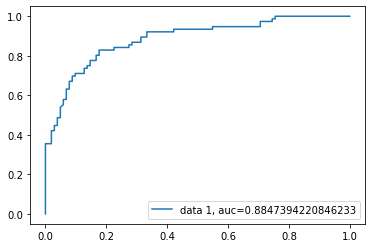

In [ ]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

AUC score for the case is 0.88. AUC score 1 represents a perfect classifier, and 0.5 represents a worthless classifier.